# Compare obs to SF and CC melt rates

Fig 3 - comparison of borehole observations with different melt parameterisations

With Rosevear et al 2022 who do a similar analysis as a comparison: https://doi.org/10.5194/os-18-1109-2022

In [1]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cmocean as cm

import matplotlib as matplotlib
plt.rcParams['hatch.color'] = 'w'
plt.rcParams['hatch.linewidth'] = 0.5
from scipy.optimize import fsolve
from gsw import CT_freezing, SA_from_SP, CT_from_pt, CT_from_t
import cartopy  # Map projections libary
import cartopy.crs as ccrs  # Projections list

Define melt param

/jobfs/144407698.gadi-pbs/ipykernel_1353612/2401909831.py:36: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last ten iterations.
  root = fsolve(func, [-1,30,-1])
/jobfs/144407698.gadi-pbs/ipykernel_1353612/2401909831.py:49: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last ten iterations.
  root = fsolve(func, [-1,30,-1])
/jobfs/144407698.gadi-pbs/ipykernel_1353612/2401909831.py:71: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last ten iterations.
  root = fsolve(func, [-1,30,1])
/jobfs/144407698.gadi-pbs/ipykernel_1353612/2401909831.py:64: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last ten iterations.
  root = fsolve(func, [-1,30,1])
/jobfs/144407698.gadi-pbs/ipykernel_1353612/2401909831.py:42: RuntimeWarning: The iteration is not making good progress, as me

Text(0.5, 0, 'friction vel, m/s')

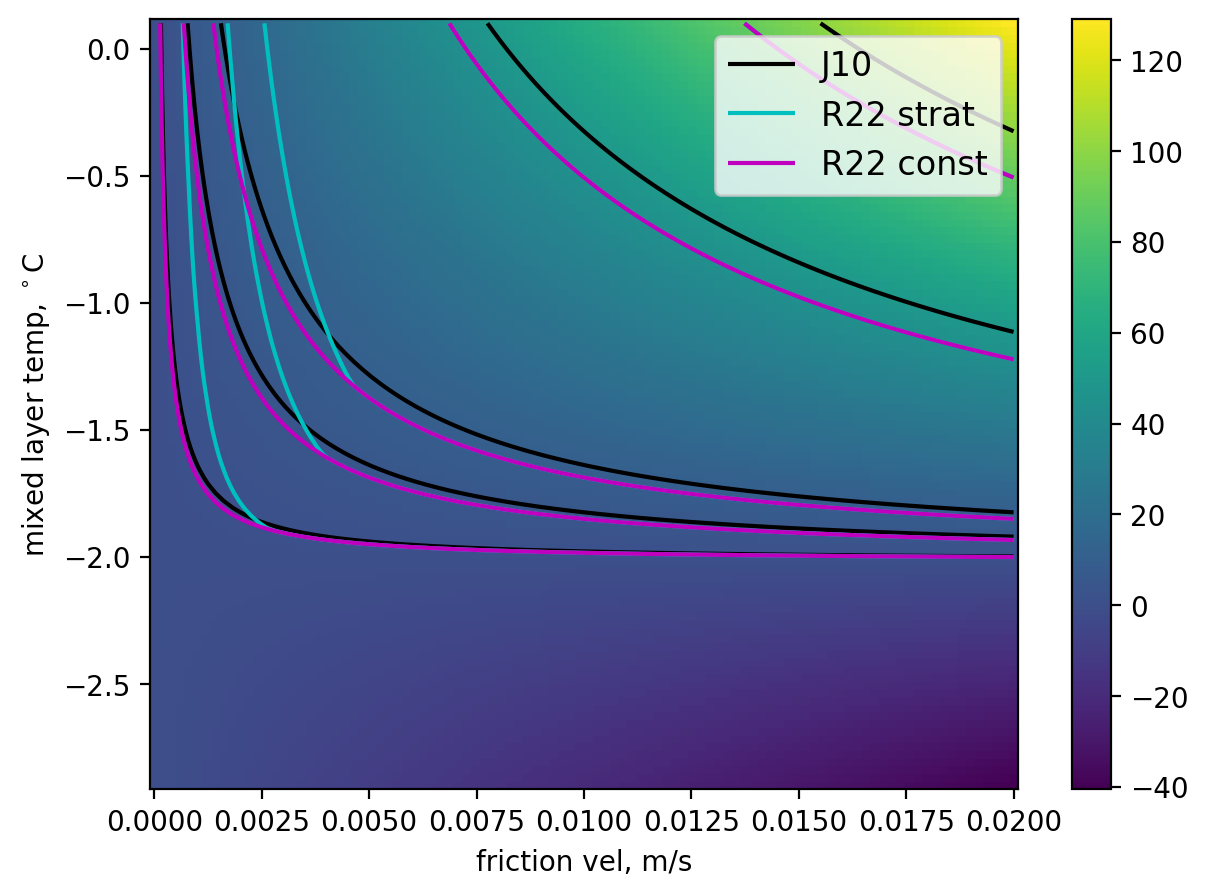

In [2]:
# python param
def solve_three_eqn_python_isomipcoeffs(ustar, depth, sst,
                    sss, J10_Gamma = True, Rosevear_Gamma = False, HJ99_Gamma = False, R22lim = False):
    
    R0 = 1030 #kg/m^3
    Cp = 3974 #J/K/kg
    lam_1 = -0.0573 #Ckg/g (salinity)
    lam_2 = -7.53e-4 #C/dbar (pressure)
    lam_3 = 0.0826 # offset
    L = 3.34e5 #J/kg
    Ri = 920 #kg/m^3
    g =9.81
    p = depth*R0*g #pascals p = rho*g*h for hydrostatic 
    p = p/1e4 #dbar
    I_VK = 1/0.41
    kv_molec = 2e-6
    dR0_dT = -0.0383569483 #[kg m-3 K-1] =alpha*R0
    dR0_dS = 0.805876093   #[kg m-3 PSU-1] =alpha*R0
    dB_dS = g/R0*dR0_dS
    dB_dT = g/R0*dR0_dT
    A =-9.89970135344883 #-9.29# -9.489
    B = 0.22260090020804837 #0.122 #0.155
    C = -7.3904118372660035 #-7.58 #-7.182
    D = 0.32220281249744703 #0.354 #0.290
    Lplus = 0
    def func(x):
        Tb,Sb,m = x
        return [Tb -lam_1*Sb-lam_2*p-lam_3,
                m - Cp/L*R0/Ri*Gam_T*ustar*(sst-Tb),
                m + R0/Ri*Gam_S*ustar*(Sb-sss)/Sb]
    
    if J10_Gamma == True:
        Gam_T = 0.011
        Gam_S = 3.1e-4

        root = fsolve(func, [-1,30,-1])
        
    elif R22lim ==True:
        Gam_T = 0.012
        Gam_S = 3.9e-4

        root = fsolve(func, [-1,30,-1])
        
    elif Rosevear_Gamma == True:
        tolerance = 1e-4
        Gam_T = 0.012
        Gam_S = 3.9e-4

        root = fsolve(func, [-1,30,-1])
        Tb,Sb,m = root
        #iterate to get convergent solution
        wB = dB_dS*(Sb-sss)*ustar*Gam_S + dB_dT*(Tb-sst)*ustar*Gam_T
        for i in np.arange(10):
            if (wB<0): #melting
                #print(i)
                Lplus = -ustar**4 * I_VK * 1.0/(kv_molec * wB)

                Gam_T = np.exp(C) * Lplus**(D) 
                Gam_S = np.exp(A) * Lplus**(B) 
                if Gam_T > 0.012:
                    Gam_T = 0.012
                if Gam_S > 3.9e-4:
                    Gam_S = 3.9e-4    
                root = fsolve(func, [-1,30,1])
                Tb,Sb,m = root
                wB = dB_dS*(Sb-sss)*ustar*Gam_S + dB_dT*(Tb-sst)*ustar*Gam_T
                Lplus_new = -ustar**4 * I_VK * 1.0/(kv_molec * wB)
                if np.abs(Lplus_new-Lplus) < tolerance:
                    break                    
            else:
                root = fsolve(func, [-1,30,1])
                break
            
    return root[0],root[1],root[2]*365*3600*24,Gam_T,Gam_S,Lplus #Tb,Sb,m in m/yr


## test

# solve_three_eqn_python(0.001, 200*9.8*1030/100, -1.5,34,J10_Gamma = True, Rosevear_Gamma = False)
fig,ax = plt.subplots(figsize = (7,5),dpi = 200)
ustar_arr = np.linspace(0,0.02,100)
sst_arr = np.linspace(-2.9,0.1,100)
melt_arr = np.zeros([100,100])
for m in np.arange(len(ustar_arr)):
    for n in np.arange(len(sst_arr)):
        #print(str(m)+', '+str(n))
        T,S,melt,Gam_T,Gam_S,Lplus = solve_three_eqn_python_isomipcoeffs(ustar_arr[m], depth = 200,sst = sst_arr[n],
                                                 sss = 34)
        melt_arr[m,n]=melt
plt.pcolormesh(ustar_arr,sst_arr,melt_arr.T)
plt.colorbar()

c1 = plt.contour(ustar_arr,sst_arr,melt_arr.T, levels = [1,5,10,50,100,200],colors = 'k')


melt_arr = np.zeros([100,100])
for m in np.arange(len(ustar_arr)):
    for n in np.arange(len(sst_arr)):
        #print(str(m)+', '+str(n))
        T,S,melt,Gam_T,Gam_S,Lplus = solve_three_eqn_python_isomipcoeffs(ustar_arr[m], depth = 200,sst = sst_arr[n],
                                                 sss = 34, J10_Gamma = False,Rosevear_Gamma = True)
        melt_arr[m,n]=melt
c2 = plt.contour(ustar_arr,sst_arr,melt_arr.T, levels = [1,5,10,50,100,200],colors = 'c')

melt_arr = np.zeros([100,100])
for m in np.arange(len(ustar_arr)):
    for n in np.arange(len(sst_arr)):
        #print(str(m)+', '+str(n))
        T,S,melt,Gam_T,Gam_S,Lplus = solve_three_eqn_python_isomipcoeffs(ustar_arr[m], depth = 200,sst = sst_arr[n],
                                                 sss = 34, J10_Gamma = False,R22lim = True,Rosevear_Gamma = False)
        melt_arr[m,n]=melt
c3 = plt.contour(ustar_arr,sst_arr,melt_arr.T, levels = [1,5,10,50,100,200],colors = 'm')
h3,l1 = c1.legend_elements()
h4,l1 = c2.legend_elements()
h5,l1 = c3.legend_elements()

#     plt.legend([h1[0],h4[0], h2[0],h5[0],h3[0]], ['KM15',r'MK18, $\theta = $'+str(theta), 'R22','R22lim','R22MK18 combo'], loc = 'upper right')

ax.legend([h3[0], h4[0],h5[0]], ['J10', 'R22 strat','R22 const'], loc = 'upper right', fontsize = 12)
ax.set_ylabel('mixed layer temp, $^\circ$C')
ax.set_xlabel('friction vel, m/s')


Check freezing point EOS

In [3]:
# def Tfreeze(S,p):
#     lam_1 = -0.069 #Ckg/g (salinity)
#     lam_2 = -7.6e-4 #C/dbar (pressure)
#     lam_3 = 0.0826 # offset
#     return lam_3+lam_1*S+lam_2*p
# print(Tfreeze(34.5,500))
def Tfreeze(S,p):
    lam_1 = -0.0573 #Ckg/g (salinity)
    lam_2 = -7.53e-4 #C/dbar (pressure)
    lam_3 = 0.0826 # offset
    return lam_3+lam_1*S+lam_2*p

print(Tfreeze(34.5,500))

-2.27075


Define some functions to plot Lplus regimes

In [17]:
def plot_R22Lplus(ax):
    verbose = False
    sss = 34.5
    ustar_arr = np.linspace(0,0.019,400)
    sst_arr = np.concatenate([np.linspace(-2.26,-2.16,201)[:-1],np.linspace(-2.16,-2.27075+5,200)])
    melt_arr_R22 = np.zeros([400,400])
    Lplus_arr = np.zeros([400,400])
    dTFr_dS = -0.0573 #degC psu-1
    dTFr_dp = -7.53E-08 #dTFr_dp = 0.0 #degC Pa-1
    Cp = 3991.86795711963 #J kg-1 K-1
    Lat_fusion = 334000 #J/kg
    TFr_0_0 = 0.0826 #degC
    #p_int = 500*1e4
    depth = 500
    def Tfreeze(S,p):
        lam_1 = -0.0573 #Ckg/g (salinity)
        lam_2 = -7.53e-4 #C/dbar (pressure)
        lam_3 = 0.0826 # offset
        return lam_3+lam_1*S+lam_2*p

    tfreeze = Tfreeze(sss,depth)#(TFr_0_0 + dTFr_dS*sss) + dTFr_dp*p_int
    tfreeze


    for m in np.arange(len(ustar_arr)):
        for n in np.arange(len(sst_arr)):
            T,S,melt,Gam_T,Gam_S,Lplus = solve_three_eqn_python_isomipcoeffs(ustar_arr[m], depth = 500,
                                                                                   sst = sst_arr[n],
                                                 sss = sss, J10_Gamma = False,Rosevear_Gamma = True)
            melt_arr_R22[m,n]=melt
            Lplus_arr[m,n] = Lplus

    Freezing_point = tfreeze 
    CS5 = ax.contour(ustar_arr,sst_arr-tfreeze,Lplus_arr.T, levels = np.array([1e2,1e3,1e4,1e5]), linewidths = [1,1,3,1],colors = 'k', linestyles = '-')
    
    h6,l1 = CS5.legend_elements()


    ax.set_xlabel('Friction Velocity, $u_*$ (m s$^{-1}$)')
    ax.set_ylabel('Thermal Driving, $T^*$ ($^\circ$C)')
    
    return h6


In [18]:
def plot_R22Lplus_with_regimes(ax):
    verbose = False
    sss = 34.5
    ustar_arr = np.linspace(0,0.019,400)
    sst_arr = np.concatenate([np.linspace(-2.76,-2.16,201)[:-1],np.linspace(-2.16,-2.27075+5,200)])
    melt_arr_R22 = np.zeros([400,400])
    Lplus_arr = np.zeros([400,400])
    dTFr_dS = -0.0573 #degC psu-1
    dTFr_dp = -7.53E-08 #dTFr_dp = 0.0 #degC Pa-1
    Cp = 3991.86795711963 #J kg-1 K-1
    Lat_fusion = 334000 #J/kg
    TFr_0_0 = 0.0826 #degC
    #p_int = 500*1e4
    depth = 500
    def Tfreeze(S,p):
        lam_1 = -0.0573 #Ckg/g (salinity)
        lam_2 = -7.53e-4 #C/dbar (pressure)
        lam_3 = 0.0826 # offset
        return lam_3+lam_1*S+lam_2*p

    tfreeze = Tfreeze(sss,depth)#(TFr_0_0 + dTFr_dS*sss) + dTFr_dp*p_int
    tfreeze


    for m in np.arange(len(ustar_arr)):
        for n in np.arange(len(sst_arr)):            
            T,S,melt,Gam_T,Gam_S,Lplus = solve_three_eqn_python_isomipcoeffs(ustar_arr[m], depth = 500,
                                                                                   sst = sst_arr[n],
                                                 sss = sss, J10_Gamma = False,Rosevear_Gamma = True)
            melt_arr_R22[m,n]=melt
            Lplus_arr[m,n] = Lplus

    Freezing_point = tfreeze 
    CS6 = ax.contourf(ustar_arr,sst_arr-tfreeze,Lplus_arr.T, levels = np.array([0,2500,1e4]),
                      cmap = cm.cm.thermal,extend = 'both',alpha = 0.15,zorder=10)
    ax.contourf(ustar_arr,sst_arr-tfreeze, np.where(melt_arr_R22.T<0,1,np.nan), levels = np.array([0.5,2]),
                cmap = 'Greys',alpha = 0.05,zorder=10)
    return CS6


In [19]:
def pressure_from_depth(depth):
    return depth*1.03 #approximate

### A list of observational data

Analysis updated from Rosevear et al. (2022). Picking out mean far-field temp, salinity, pressure, velocity and observational melt rate to compare with three-equation parameterisation. In some cases visual inspection was used on figure plots, details in the dictionary below.

**Amery** - Rosevear, M. G., Galton-Fenzi, B., and Stevens, C.: Evaluation of basal melting parameterisations using in situ ocean and melting observa-
tions from the Amery Ice Shelf, East Antarctica, Ocean Science, 18, 1109–1130, https://doi.org/0.5194/os-18-1109-2022, 2022a.

**FRIS** - Jenkins, A., Nicholls, K. W., and Corr, H. F.: Observation and parameterization of ablation at the base of Ronne Ice Shelf, Antarctica, Journal
of Physical Oceanography, 40, 2298–2312, https://doi.org/10.1175/2010JPO4317.1, 2010.

**Larsen C** - Davis, P. E. and Nicholls, K. W.: Turbulence observations beneath Larsen C ice shelf, Antarctica, Journal of Geophysical Research: Oceans,
124, 5529–5550, https://doi.org/10.1029/2019JC015164, 2019

**George VI** - Kimura, S., Nicholls, K. W., and Venables, E.: Estimation of ice shelf melt rate in the presence of a thermohaline staircase, Journal of Physical
Oceanography, 45, 133–148, https://doi.org/10.1175/JPO-D-14-0106.1, 2015. and Middleton, L., Davis, P., Taylor, J., and Nicholls, K.: Double diffusion as a driver of turbulence in the stratified boundary layer beneath
George VI Ice Shelf, Geophysical Research Letters, 49, e2021GL096 119, https://doi.org/10.1029/2021GL096119, 2022

**Ross Winter and Summer** - Stewart, C. L.: Ice-ocean interactions beneath the north-western Ross Ice Shelf, Antarctica, Ph.D. thesis,
https://doi.org/10.17863/CAM.21483, 2018.

**Pine Island** - Stanton, T. P., Shaw, W., Truffer, M., Corr, H., Peters, L., Riverman, K., Bindschadler, R., Holland, D., and Anandakrishnan,
S.: Channelized ice melting in the ocean boundary layer beneath Pine Island Glacier, Antarctica, Science, 341, 1236–1239,
https://doi.org/10.1126/science.1239373, 2013.

**WGZ (Ross)** - Begeman, C. B., Tulaczyk, S. M., Marsh, O. J., Mikucki, J. A., Stanton, T. P., Hodson, T. O., Siegfried, M. R., Powell, R. D., Christianson,
K., and King, M. A.: Ocean stratification and low melt rates at the Ross Ice Shelf grounding zone, Journal of Geophysical Research:
Oceans, 123, 7438–7452, https://doi.org/10.1029/2018JC013987, 2018.

**Thwaites** - Davis, P. E., Nicholls, K. W., Holland, D. M., Schmidt, B. E., Washam, P., Riverman, K. L., Arthern, R. J., Vaˇnková, I., Eayrs, C., Smith, J. A.,
et al.: Suppressed basal melting in the eastern Thwaites Glacier grounding zone, Nature, 614, 479–485, https://doi.org/10.1038/s41586-
022-05586-0, 2023.



In [20]:
Obs = {'Amery':{'T_m':-2.1 , ## conservative temp, average of blue line, Fig. 4a (visual inspection, Thermal driving of 0.19K given)
              'S_m':34.59, ## absolute salt, average of blue line, Fig. 4b (visual inspection)
              'depth':523, #given
              'u':4e-2, #given, Table 4
              'obsm':0.46, #given, Table 4
              'madiJ10':1.9,
              'madiTstar':0.19,
              'color':'#332288',
             'lat':-70.25,'lon':71.5},
       'FRIS':{
           'T_m_i':-2.39 , # assumed to be in situ temperature but not explicitly said ## average of Fig 4 (visual inspection)
           'S_m_p':34.51, # practical salt #given, assumed constant in their calcs
           'depth':700, #ice is 816m thick, so pressure = 0.9*816 \appox 700
           'u':6e-2, # hard to visually inspect plot, and its only for one day. Could be between 5-15cm/s from one day snapshot. Definitely needs asterisk
           'obsm':0.554, 'madiJ10':0.553,
              'madiTstar':0.05, #approximate
           'color':'#117733',
              'lat':-77,'lon':-65},
       'Larsen C':{'T_m_p':-2.08 , #potential temperature #given
               'S_m_p':34.54, # practical salinity #given to be assumed
               'depth':304, #given
               'u':7e-2, #taken from R22, which was calculated from figure
               'obsm':0.7, 'madiJ10':0.69,
               'madiTstar':0.05,
               'color':'#44AA99',
              'lat':-68.25,'lon':-63.3}, 
       'George VI':{'T_m_p':0.3 , #potential temperature #given 20m below ice
               'S_m':34.62,  #absolute salinity #given 20m below ice
               'depth':317,  #given ice thickness of 380 (middleton 2022)-> pressure of 380*0.9=340
               'u':4e-2, ## Middleton 2022 gives u of 4cm/s and ustar around 0.1cm/s (visual inspection)
               'obsm':1.4, 'madiJ10':71,
               'madiTstar':2.3, 
               'color':'#88CCEE',
              'lat':-72.8,'lon':-70.8},
       'Ross W':{'T_m_p':-1.9375 , #assumed potential temp #average of winter results, table 3.2
                'S_m_p':34.5, #assumed psu #winter mean of Fig 2.5 (visual inspection)
                'depth':229, #pressure of TS logger #1
                'u':12.5e-2, #average of summer results, table 3.2
                'obsm':1.4, #average of summer results, table 3.2
                'madiJ10':3.8,
                'madiTstar':0.12, 
                'color':'#DDCC77',
               'lat':-77.3,'lon':171.5},
       'Ross S':{'T_m_p':-1.68 ,  #assumed potential temp#average of summer results, table 3.2
                'S_m_p':34.3, #assumed psu #summer mean of Fig 2.5 (visual inspection)
                'depth':229, #pressure of TS logger #1
                'u':10e-2, #average of summer results, table 3.2
                'obsm':2.7, #average of summer results, table 3.2
                'madiJ10':10,
                'madiTstar':0.38, 
                'color':'#CC6677',
               'lat':-77.3,'lon':171.5}, #S??
       'Pine Island':{'T_m':-0.82 , # back calculated from 1.4 degrees departure of freezing and my freezing EOS
               'S_m_p':33.85, #practical salinity #given
               'depth':460, #given
               'u':13e-2, #average of given range
               'obsm':14.6, 'madiJ10':50,
               'madiTstar':1.39, #plot shows departure from freezing of 1.4
               'color':'#AA4499',
              'lat':-75,'lon':-101},
       'WGZ (Ross)':{'T_m': -2.3, #conservative temp #average of UL temp (tavble 2)
                   'S_m':34.74, #absolute salinity #average of UL salinity Ttable 2)
                   'depth':665, # (Fig 3)
                   'u':1.5e-2, #given
                   'obsm':0.05, 'madiJ10':0.24, 
                   'madiTstar':0.1, #given tstar of 0.1
                   'color':'#882255',
                  'lat':-80,'lon':-160},
       'Thwaites': #from inspection of Davis 2022 figures
       {'T_m': -0.3, #conservative temp #visual inspection of Fig 3a
        'S_m':34.38, #absolute salinity #visual inspection of Fig 3a
        'depth':515, #Fig 2
        'u':3e-2, #visual inspection of Extended Data Fig 4a
        'obsm':3.8, #average of given range
        'madiJ10':15,#from Davis23 not R22
        'madiTstar':2, #from Davis23 not R22
        'color':'k',
       'lat':-75.2,'lon':-104.8},
       
       }


If not in conservative temp or absolute salt units, convert.

In [21]:
# do some conversion to absolute salt and conservative temperature if not already in that format

#gsw_SA_from_SP(SP,p,long,lat)
#CT = gsw_CT_from_pt(SA,pt)
#gsw_CT_from_t(SA,t,p)
#p   =  sea pressure                                              [ dbar ]
#       ( i.e. absolute pressure - 10.1325 dbar )

#convert FRIS practical salt into abs salt and presumed in situ temp into conservative temp
Obs['FRIS']['S_m'] = SA_from_SP(Obs['FRIS']['S_m_p'],
                                pressure_from_depth(Obs['FRIS']['depth'])-10.13, #sea pressure in gsw
                                Obs['FRIS']['lon'],Obs['FRIS']['lat'])
Obs['FRIS']['T_m'] = CT_from_t(Obs['FRIS']['S_m'],Obs['FRIS']['T_m_i'],
                              pressure_from_depth(Obs['FRIS']['depth'])-10.13)

#convert Larsen C practical salt into abs salt and potential temp into conservative temp

for loc in ['Larsen C','Ross S','Ross W']:
    Obs[loc]['S_m'] = SA_from_SP(Obs[loc]['S_m_p'],
                                    pressure_from_depth(Obs[loc]['depth'])-10.13, #sea pressure in gsw
                                    Obs[loc]['lon'],Obs[loc]['lat'])
    Obs[loc]['T_m'] = CT_from_pt(Obs[loc]['S_m'],Obs[loc]['T_m_p'])

#convert George VI potential temp into conservative temp

for loc in ['George VI']:
    Obs[loc]['T_m'] = CT_from_pt(Obs[loc]['S_m'],Obs[loc]['T_m_p'])

#convert Pine Island practical salt into abs salt

for loc in ['Pine Island']:

    Obs[loc]['S_m'] = SA_from_SP(Obs[loc]['S_m_p'],
                                pressure_from_depth(Obs[loc]['depth'])-10.13, #sea pressure in gsw
                                Obs[loc]['lon'],Obs[loc]['lat'])


Check

In [22]:
Obs

{'Amery': {'T_m': -2.1,
  'S_m': 34.59,
  'depth': 523,
  'u': 0.04,
  'obsm': 0.46,
  'madiJ10': 1.9,
  'madiTstar': 0.19,
  'color': '#332288',
  'lat': -70.25,
  'lon': 71.5},
 'FRIS': {'T_m_i': -2.39,
  'S_m_p': 34.51,
  'depth': 700,
  'u': 0.06,
  'obsm': 0.554,
  'madiJ10': 0.553,
  'madiTstar': 0.05,
  'color': '#117733',
  'lat': -77,
  'lon': -65,
  'S_m': 34.679435833795644,
  'T_m': -2.400528399359001},
 'Larsen C': {'T_m_p': -2.08,
  'S_m_p': 34.54,
  'depth': 304,
  'u': 0.07,
  'obsm': 0.7,
  'madiJ10': 0.69,
  'madiTstar': 0.05,
  'color': '#44AA99',
  'lat': -68.25,
  'lon': -63.3,
  'S_m': 34.709331134617955,
  'T_m': -2.0766679617771158},
 'George VI': {'T_m_p': 0.3,
  'S_m': 34.62,
  'depth': 317,
  'u': 0.04,
  'obsm': 1.4,
  'madiJ10': 71,
  'madiTstar': 2.3,
  'color': '#88CCEE',
  'lat': -72.8,
  'lon': -70.8,
  'T_m': 0.30219095576752836},
 'Ross W': {'T_m_p': -1.9375,
  'S_m_p': 34.5,
  'depth': 229,
  'u': 0.125,
  'obsm': 1.4,
  'madiJ10': 3.8,
  'madiTstar'

#### Plot

/jobfs/144407698.gadi-pbs/ipykernel_1353612/2401909831.py:64: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last ten iterations.
  root = fsolve(func, [-1,30,1])
/jobfs/144407698.gadi-pbs/ipykernel_1353612/2401909831.py:49: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last ten iterations.
  root = fsolve(func, [-1,30,-1])


Thermal Driving 0.20504056999999998
Madi TD 0.19
Amery R22 const coeff mr =  1.1730944218633752
Amery R22 strat mr =  0.8722706519432604 impliedLplus 3516.7088536075235
Thermal Driving 0.04691627391748954
Madi TD 0.05
FRIS R22 const coeff mr =  0.3214637477529225
FRIS R22 strat mr =  0.32146374775208747 impliedLplus 46479.31533088729
Thermal Driving 0.0653560722364932
Madi TD 0.05
Larsen C R22 const coeff mr =  0.624900850633721
Larsen C R22 strat mr =  0.6249008506337218 impliedLplus 44510.91675077972
Thermal Driving 2.449178985767528
Madi TD 2.3
George VI R22 const coeff mr =  17.009312687259953
George VI R22 strat mr =  7.4035730616106274 impliedLplus 633.7943464410033
Thermal Driving 0.14742075742063876
Madi TD 0.12
Ross W R22 const coeff mr =  2.661050709061624
Ross W R22 strat mr =  2.6610507090616693 impliedLplus 108561.17216369027
Thermal Driving 0.3936018195976516
Madi TD 0.38
Ross S R22 const coeff mr =  5.903895820526943
Ross S R22 strat mr =  5.903895820526943 impliedLplus 

/jobfs/144407698.gadi-pbs/ipykernel_1353612/2401909831.py:49: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last ten iterations.
  root = fsolve(func, [-1,30,-1])
/jobfs/144407698.gadi-pbs/ipykernel_1353612/2401909831.py:64: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last ten iterations.
  root = fsolve(func, [-1,30,1])
/jobfs/144407698.gadi-pbs/ipykernel_1353612/2401909831.py:71: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last ten iterations.
  root = fsolve(func, [-1,30,1])
/jobfs/144407698.gadi-pbs/ipykernel_1353612/2364254250.py:108: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  for pc in CS6.collections]


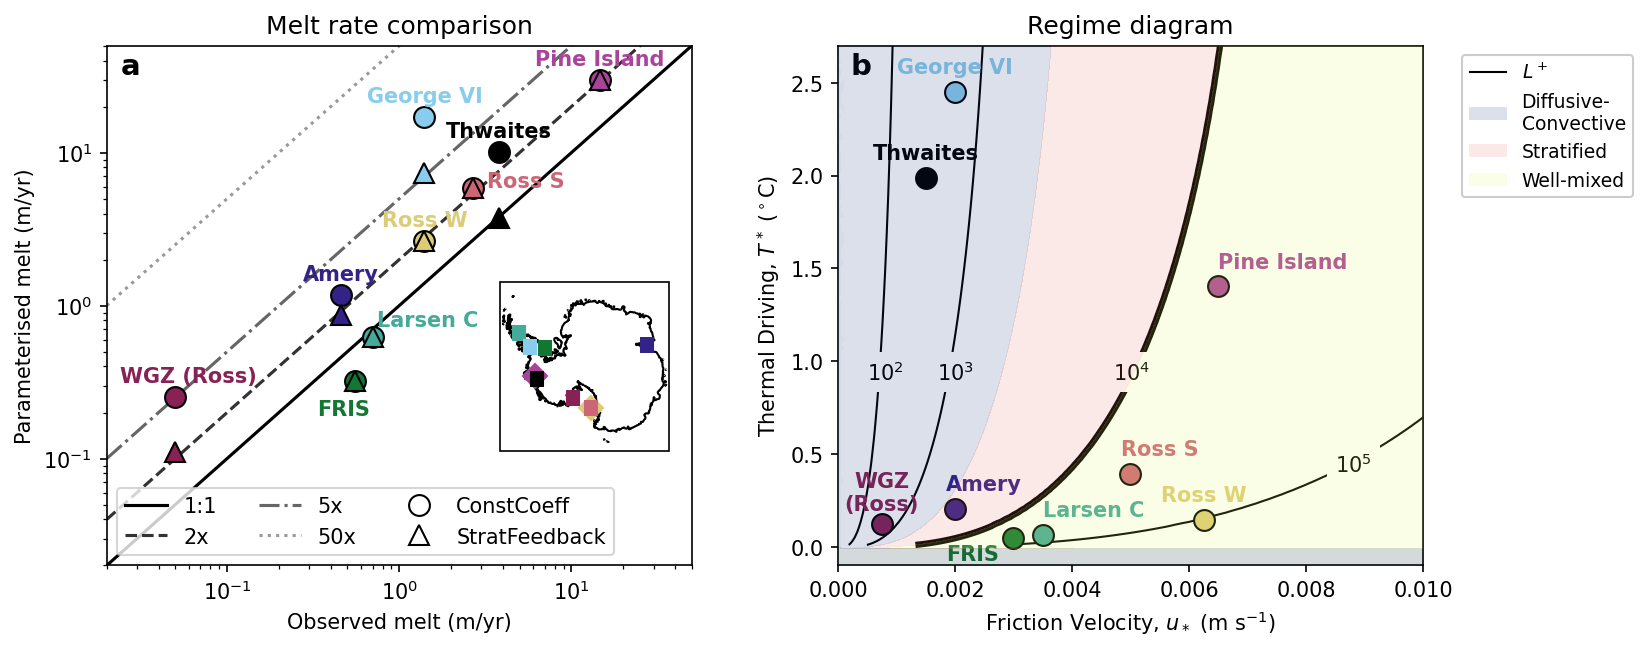

In [23]:
fig, axes = plt.subplots( figsize = (13,4.5),dpi = 150, ncols = 2)

h6 = plot_R22Lplus(axes[1])

#for name in Obs:

axes[0].plot([0.02,100],[0.02,100],'-k', label = '1:1')
axes[0].plot([0.02,100],[0.04,200],'--k', label = '2x',alpha = 0.8)
axes[0].plot([0.02,100],[0.1,500],'-.k', label = '5x',alpha = 0.6)
axes[0].plot([0.02,100],[0.02*50,100*50],':k', label = '50x',alpha = 0.4)

ax_inset = plt.axes([0.245,0.28,0.25,0.25],projection=ccrs.SouthPolarStereo())
ax_inset.set_extent([-180, 180, -90, -65], ccrs.PlateCarree())
ax_inset.coastlines()
#ax_inset.axis('off')


for k, d in Obs.items():

    ustar_J10 = d['u']*np.sqrt(0.0097)
    ustar_isomip = d['u']*np.sqrt(0.0025)
    #if k == 'G VI':
    #    ustar_isomip = 0.1e-2 #m/s from Middleton et al. 2022
    ThermalDriving = d['T_m'] - Tfreeze(d['S_m'],pressure_from_depth(d['depth']))
    #print(d['T_m'])
    #print(Tfreeze(d['S_m'],d['depth']))
    print('Thermal Driving',ThermalDriving)
    print('Madi TD',d['madiTstar'])
    
    T,S,meltR22lim,GT,GS,Lplus = solve_three_eqn_python_isomipcoeffs(ustar_isomip, d['depth'], 
                                                            d['T_m'], d['S_m'],
                                                            J10_Gamma = False, Rosevear_Gamma = False,R22lim = True)
    axes[0].plot( d['obsm'],meltR22lim, 'o', color = d['color'], markersize = 10, mec = 'k')
    print(k,'R22 const coeff mr = ',meltR22lim)
    T,S,meltR22strat,GT,GS,Lplus = solve_three_eqn_python_isomipcoeffs(ustar_isomip, d['depth'], 
                                                            d['T_m'], d['S_m'],
                                                            J10_Gamma = False, Rosevear_Gamma = True)
    axes[0].plot( d['obsm'],meltR22strat, '^',color = d['color'], markersize = 10, mec = 'k')
    print(k,'R22 strat mr = ',meltR22strat, 'impliedLplus',Lplus)
    #cs = axes[1].plot( ustar_isomip,ThermalDriving, label = k,color='black',marker='o', markersize = 10,markerfacecolor = d['color'])
    cs = axes[1].plot( ustar_isomip,ThermalDriving, 'o',color = d['color'],markersize = 10, mec = 'k')
    if (k=='FRIS'):
        axes[0].text(d['obsm']*0.6,meltR22lim*0.6,k,ha = 'left',color = d['color'],fontweight = 'bold')  
    elif (k == 'Larsen C'):
        axes[0].text(d['obsm']*2.1,meltR22lim*1.5,k,ha = 'center', va = 'top',color = d['color'],fontweight = 'bold')  
    elif (k == 'Ross S'):
        axes[0].text(d['obsm']*1.2,meltR22lim*1,k,ha = 'left',color = d['color'],fontweight = 'bold')  
    elif (k == 'WGZ (Ross)'):
        axes[0].text(d['obsm']*1.2,meltR22lim*1.25,k,ha = 'center',color = d['color'],fontweight = 'bold')
    else:
        axes[0].text(d['obsm'],meltR22lim*1.25,k,ha = 'center',color = d['color'],fontweight = 'bold')
    if (k == 'Larsen C') or (k == 'Pine Island'):
        axes[1].text(ustar_isomip,ThermalDriving+0.1,k,ha = 'left',color = d['color'],fontweight = 'bold')        
    elif (k == 'WGZ (Ross)'):
        axes[1].text(ustar_isomip,ThermalDriving+0.05,'WGZ\n(Ross)',ha = 'center',va = 'bottom',color = d['color'],fontweight = 'bold')        
    elif (k == 'FRIS'):
        axes[1].text(ustar_isomip-0.00025,ThermalDriving-0.03,k,ha = 'right',va = 'top',color = d['color'],fontweight = 'bold')                
    elif (k == 'Amery') or (k == 'Ross S'):
        axes[1].text(ustar_isomip+0.0005,ThermalDriving+0.1,k,ha = 'center',color = d['color'],fontweight = 'bold')        
    else:
        axes[1].text(ustar_isomip,ThermalDriving+0.1,k,ha = 'center',color = d['color'],fontweight = 'bold')
    if (k == 'Pine Island'):
        ax_inset.plot(d['lon'],d['lat'],'D',color = d['color'],markersize = 8,transform=ccrs.PlateCarree())
    elif (k == 'Ross W'):
        ax_inset.plot(d['lon'],d['lat'],'D',color = d['color'],markersize = 8,transform=ccrs.PlateCarree())        
    else:
        ax_inset.plot(d['lon'],d['lat'],'s',color = d['color'],markersize = 6,transform=ccrs.PlateCarree())
    
axes[0].plot( 0.0001,0.0001, 'o', color = 'w', mec = 'k',markersize = 10, label = 'ConstCoeff')
axes[0].plot( 0.0001,0.0001, '^',color = 'w', mec = 'k',markersize = 10, label = 'StratFeedback')

axes[0].legend(ncol = 3,loc = 'lower left')#,bbox_to_anchor = (0.02,0.98))

axes[0].set_xlabel('Observed melt (m/yr)')
axes[0].set_ylabel('Parameterised melt (m/yr)')
axes[0].set_xscale('log')
axes[0].set_yscale('log')
axes[0].set_xlim(0.02,50)
axes[0].set_ylim(0.02,50)
axes[0].set_title('Melt rate comparison');
#axes[1].set_yscale('log')
#axes[1].set_xscale('log')
axes[1].set_ylim(-0.1,2.7)
axes[1].set_xlim(0,0.01)
axes[1].set_title('Regime diagram')
axes[0].text(0.04,0.96,'a',horizontalalignment='center', fontweight='bold',
     verticalalignment='center',transform=axes[0].transAxes, fontsize = 14)
axes[1].text(0.04,0.96,'b',horizontalalignment='center', fontweight='bold',
     verticalalignment='center',transform=axes[1].transAxes, fontsize = 14)

cs =cm.cm.thermal(np.array([75,100,150,250]))
purple = (cs[0,0],cs[0,1],cs[0,2])
red = (cs[2,0],cs[2,1],cs[2,2])
yellow = (cs[3,0],cs[3,1],cs[3,2])

t = axes[1].text(0.0005,0.9,r'$10^2$',fontsize = 10)
t.set_bbox(dict(facecolor='white', alpha=1, linewidth=0))
t = axes[1].text(0.0017,0.9,r'$10^3$',fontsize = 10)
t.set_bbox(dict(facecolor='white', alpha=1, linewidth=0))
t = axes[1].text(0.0047,0.9,r'$10^4$',fontsize = 10)
t.set_bbox(dict(facecolor='white', alpha=1, linewidth=0))
t = axes[1].text(0.0085,0.4,r'$10^5$',fontsize = 10)
t.set_bbox(dict(facecolor='white', alpha=1, linewidth=0))

CS6 = plot_R22Lplus_with_regimes(axes[1])

proxy = [plt.Rectangle((0,0),1,1,fc = pc.get_facecolor()[0]) 
    for pc in CS6.collections]
axes[1].legend([h6[0]]+proxy[1:], ["$L^+$","Diffusive-\nConvective", "Stratified", "Well-mixed"], 
               loc = 'upper left', bbox_to_anchor = (1.05,1),
              facecolor='white', fontsize = 9, framealpha=1)

fig.subplots_adjust(wspace = 0.25, right = 0.8)
fig.savefig('/g/data/x77/cy8964/ISOMIP/param-paper-plots/figs/Fig3.png', dpi = 300)